In [1]:
import sys
sys.path.append('../functions')
import numpy as np
#import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
#import torch
import pandas as pd
import multiprocessing
import time
from sklearn.model_selection import ParameterGrid
import linear_sim_func  

In [3]:
!python3 ../functions/main_linear.py

Runtime of the program is 0.10036563873291016 seconds


# One simulation 

In [25]:
n_sim = 1
#closeness_v = [0.5,0.1,0.01,0.001]
#closeness_v = [ -x for x in closeness_v]
N_v = [200]
N_test_v = [500]
p_v = [50]
error_sd_v = [1]
L_v = [0.95]
level_v = [1]
use_true_contour_v = [False]
n_boot_v = [500]
ridge_v = [False]
df_result = []
param_grid = {'N': N_v, 'N_test': N_test_v, 'p': p_v , 'error_sd': error_sd_v, 'L': L_v,
              'level': level_v,  'use_true_contour': use_true_contour_v, 'n_boot':n_boot_v, 'ridge':ridge_v}
param_grid = ParameterGrid(param_grid)
# "contain", "N", "N_test",
#                                 "p", "error_sd", "level", "use_true_contour",
#                                 "contain_scb","contain_CS_scb","Lower_bound",
#                                 "Upper_bound", "L1", "L2", "U1", "U2", "points_in_e1", 
#                                 "pre_mae", 'inner_points_num', 'outer_points_num' ,'true_set_points_num'
for param in param_grid:
    (contain, N, N_test, p, error_sd, level, use_true_contour, contain_scb, 
     contain_CS_scb, L, U, L1, L2, U1, U2, n_points, mae,
     range_v, inner_points_num,outer_points_num,true_set_points_num) = linear_sim_func.sim_linear(param['N'], param['N_test'], param['p'], param['error_sd'], 
                                                                                           param['L'],param['level'],param['use_true_contour'], 
                                                                                           param['n_boot'], param['ridge'],return_range = True)

In [26]:
mae

0.610364083223544

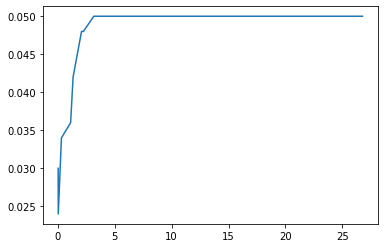

0.9500000000000028
0.974
True
0.752
0.9500000000000028
0.974
0.982
2


In [10]:
from matplotlib import pyplot as plt
x = [z[0] for z in range_v]
y = [z[1] for z in range_v]
plt.plot(x,y)
plt.show()
print(L)
print(U)
print(contain)
print(L1)
print(L2)
print(U1)
print(U2)
print(n_points)

# Multiple simulations (only works for MacOS)

In [4]:
from datetime import date
today = date.today()
date = today.strftime("%d%m%Y")
file_name = 'sim_results_boot_2000'+date+'.csv'
df_total = pd.DataFrame()
n_sim = 2
N_v = [50]
N_test_v = [500]
p_v = [160]
error_sd_v = [1]
L_v = [0.95]
level_v = [0.2]
use_true_contour_v = [False]
n_boot_v = [2000]
ridge_v = [True]
df_result = []
param_grid = {'N': N_v, 'N_test': N_test_v, 'p': p_v , 'error_sd': error_sd_v, 'L': L_v,
              'level': level_v,  'use_true_contour': use_true_contour_v, 'n_boot':n_boot_v,'ridge':ridge_v}
param_grid = ParameterGrid(param_grid)
start = time.time()
for param in param_grid:
    df = pd.DataFrame(param, index = [0])
    para_df = pd.DataFrame(np.repeat(df.values,n_sim, axis=0))
    para_df.columns = df.columns
    pool_obj = multiprocessing.Pool()
    cur_para = (n_sim*((param['N'], param['N_test'], param['p'], param['error_sd'], \
                      param['L'],param['level'],param['use_true_contour'], param['n_boot'], param['ridge']),))
    df_result.append(np.array(pool_obj.starmap(linear_sim_func.safe_sim_linear,cur_para)))
    pool_obj.close()
    pool_obj.join()
    df_ = pd.DataFrame(np.concatenate(df_result, axis = 0), 
                 columns = ["contain","contain_scb","contain_CS_scb","Lower_bound",
                            "Upper_bound", "L1", "L2", "U1", "U2", "points_in_e1", 
                            "pre_mae", 'inner_points_num', 'outer_points_num' ,'true_set_points_num'])
    df_ = pd.concat([para_df, df_], axis = 1)
    df_total = pd.concat([df_total,df_])
    df_total.to_csv(file_name, index = False)
end = time.time()
print('Runtime of the program is ' + str(end -start) + ' seconds')

ValueError: Shape of passed values is (2, 15), indices imply (2, 14)

In [ ]:
df_total[df_total.use_true_contour==0].mean()

# Using scripts to run (for Windows Ubuntun)

In [28]:
!python3 main.py

Runtime of the program is 281.3313100337982 seconds


# Bootstrap quantile vs True quantile

In [2]:
import bootstrap_func
from linear_sim_func import *
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
# bootstrap
N = 150
N_test = 500
p = 160
beta =None
error_sd = 1
X_test = None
ridge_penal = 0.01
n_boot = 2000
smoothed = False
residual_boot = False
CV_boot = True
#bias_correction = True
if beta is None:
    rng = np.random.default_rng(None)
    beta = rng.standard_normal(size = p)
y,X, X_test, mean_test_true = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
if ridge_penal is not None:
    penal_sizes = [1,0.5,1e-1, 1e-2, 1e-3, 1e-4]
    clf = RidgeCV(alphas = penal_sizes, store_cv_values = True).fit(X, y)
    errors = np.mean(clf.cv_values_, axis = 0)
    ridge_penal = penal_sizes[np.argmin(errors)]
print(ridge_penal)

1


In [4]:
 sim_linear(N, N_test, p, error_sd, L = 0.925, level= 0.2, use_true_contour = False, n_boot = 500, ridge_penal = penal_sizes, MC = True, smoothed = False, residual_boot = False, CV_boot = False, beta = None, X_test = None,  return_range = False)

> /mnt/c/Users/a1382/OneDrive/Desktop/prediction_uncertainty/functions/linear_sim_func.py(82)sim_linear()
     80         else:
     81             import pdb; pdb.set_trace()
---> 82             mean = ridge_linear_fit_predict(y, X, X_test, best_penal) if ridge_penal is not None else linear_fit_predict(y, X, X_test)
     83     else:
     84         y,X, X_test, mean_test_true = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)



ipdb>  c


(True,
 True,
 True,
 0.9260000000000446,
 0.972,
 0.7879999999999998,
 0.9260000000000446,
 0.972,
 1.0,
 68,
 3.7543576826444163,
 22.01154941041574,
 40,
 460,
 238)

In [3]:
if ridge_penal is not None:
    mean, se, mean_boot_l = bootstrap_func.fit_bootstrap_ridge(y = y, 
                                          X = X, X_test = X_test, n_boot = n_boot,  penal_size = ridge_penal, 
                                                               smoothed = smoothed, residual_boot = residual_boot, CV_boot = CV_boot)
    #mean_linear = linear_fit_predict()
else:# linear model without penality
    mean, se, mean_boot_l = bootstrap_func.fit_bootstrap( y = y, 
                                          X = X, X_test = X_test, n_boot = n_boot, smoothed = smoothed, residual_boot =  residual_boot)

mean_bias_cor = 2*mean - np.mean(mean_boot_l, axis = 0)
# MCMC    
mean_MC_l = []
for i in range(n_boot):
    y_new,X_new, X_test_trash, mean_test_true_trash = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
    if ridge_penal is not None:
        if CV_boot:
            clf = RidgeCV(alphas = penal_sizes, store_cv_values = True).fit(X_new, y_new)
            mean_MC_l.append(clf.predict(X_test))
        else:
            mean_MC_l.append(ridge_linear_fit_predict(y_new, X_new, X_test, ridge_penal) )
    else:# linear model without penality
        mean_MC_l.append(linear_fit_predict(y_new, X_new, X_test) )
mean_MC_l = np.array(mean_MC_l)
se_MC = np.std(mean_MC_l, axis = 0)
if smoothed:
    mean_MC = np.mean(mean_MC_l, axis = 0)
else:
    mean_MC = ridge_linear_fit_predict(y, X, X_test, ridge_penal) if ridge_penal is not None else linear_fit_predict(y, X, X_test) 

1.000000000000001
0.9999999999999998
1.6624566722611038
1.4031062812185786
-1.2286119672771103
-1.4648592229196127
2.002416684653056
2.032166423497684
0.13267009700155524
0.14070518348075545


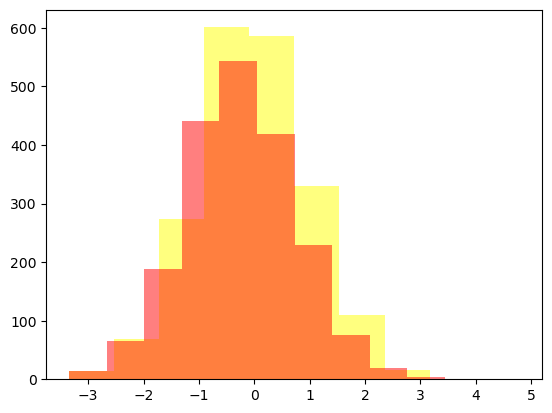

In [8]:
i = 5
G = (mean_boot_l-np.mean(mean_boot_l,axis = 0))/se
#np.mean(mean_boot_l,axis = 0)
G_MC = (mean_MC_l-mean_test_true)/se_MC
plt.hist(G[:,i], color = 'yellow', alpha=0.5)
plt.hist(G_MC[:,i], color = 'red', alpha=0.5)
# plt.hist(mean_boot_l[:,i], color = 'yellow', alpha=0.5)
# plt.hist(mean_MC_l[:,i], color = 'red', alpha=0.5)
# plt.axvline(mean[i], color='yellow', linestyle='dashed', linewidth=1)
# #plt.axvline(mean_bias_cor[i], color='green', linestyle='dashed', linewidth=1)
# plt.axvline(mean_test_true[i], color='red', linestyle='dashed', linewidth=1)
# print(np.std(mean_boot_l[:,i]))
# print(np.std(mean_MC_l[:,i]))
# print(np.quantile(mean_boot_l[:,i], q = 0.95))
# print(np.quantile(mean_MC_l[:,i], q = 0.95))
print(np.std(G[:,i]))
print(np.std(G_MC[:,i]))
print(np.quantile(G[:,i], q = 0.95))
print(np.quantile(G_MC[:,i], q = 0.95))
print(np.quantile(G[:,i], q = 0.1))
print(np.quantile(G_MC[:,i], q = 0.1))
print(np.quantile(np.abs(G[:,i]), q = 0.95))
print(np.quantile(np.abs(G_MC[:,i]), q = 0.95))
print(np.quantile(np.abs(G[:,i]), q = 0.1))
print(np.quantile(np.abs(G_MC[:,i]), q = 0.1))

In [5]:
print(np.mean(np.std(mean_boot_l, axis = 0) > np.std(mean_MC_l, axis = 0)))
print(np.mean(np.abs((np.std(mean_boot_l, axis = 0) - np.std(mean_MC_l, axis = 0)))))

0.996
0.6147733047580812


In [74]:
mean[16]

-19.21632190769464

In [432]:
np.mean(mean_boot_l, axis = 0)[16]

9.672344929039511

In [424]:
np.mean(mean_boot_l[:,i])

-6.330184772354789